# 05b - So sanh Tracking: ByteTrack vs BoT-SORT vs OC-SORT vs Deep OC-SORT vs FastTracker vs TrackTrack

**Ca 6 tracker deu tich hop SAN trong `ultralytics` (tu ban v8.4.63 tro len)** - chi
doi ten file YAML o tham so `tracker=`, khong can cai them package/model rieng nao:

| Tracker | File config | Dac diem chinh |
|---|---|---|
| ByteTrack | `bytetrack.yaml` | Cần baseline nhanh nhất, đơn giản nhất? → ByteTrack (không ReID, không bù chuyển động camera, overhead tối thiểu). |
| BoT-SORT | `botsort.yaml` | Cảnh quay cầm tay, drone, hoặc camera di động? → BoT-SORT (mặc định; thêm bù chuyển động camera và ReID tùy chọn). |
| OC-SORT | `ocsort.yaml` | Chuyển động phi tuyến tính (thể thao, khiêu vũ, rẽ đột ngột) và không cần ReID? → OC-SORT (hiệu chỉnh theo quan sát mà không mất chi phí về diện mạo). |
| Deep OC-SORT | `deepocsort.yaml` | Các cảnh quay camera di động đông đúc nơi hoán đổi ID là vấn đề chính? → Deep OC-SORT hoặc TrackTrack (cả hai đều thêm hợp nhất diện mạo thích ứng; TrackTrack cũng thêm liên kết đa tín hiệu và triệt tiêu trùng lặp ID). |
| FastTracker | `fasttrack.yaml` | ByteTrack + xu ly che khuat (occlusion-aware), Thường xuyên chồng lấp một phần trong thời gian thực, không có ngân sách cho ReID? |
| TrackTrack | `tracktrack.yaml` | Association da tieu chi (IoU+ReID+conf+goc), manh nhat cho canh dong nguoi che khuat |

**Thiet ke thi nghiem:** co dinh detector la **YOLOv8n** cho ca 6 lan chay - chi doi
thuat toan tracking, khong doi detector, de so sanh cong bang. Dung config MAC DINH
cua tung tracker (khong bat `with_reid`) de danh gia "ngay khi dung ra, khong chinh
tay" - neu muon thu nghiem sau hon co the bat ReID rieng cho BoT-SORT/Deep OC-SORT/
TrackTrack sau (xem ghi chu cuoi notebook).

**Luu y quan trong:** chay 6 tracker se lau hon dang ke so voi 2 tracker truoc day -
can kien nhan doi, dac biet neu chay tren CPU.

In [1]:
# ===== CELL 1: Thiet lap duong dan =====
import os

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = r'D:\Code\Face recognition security system'
AI_DIR = os.path.join(BASE_DIR, 'ai')
BENCHMARK_DIR = os.path.join(AI_DIR, 'dataset', 'benchmarks')
RESULTS_DIR = os.path.join(AI_DIR, 'models', 'tracker_results')
os.makedirs(RESULTS_DIR, exist_ok=True)

MOT_SEQUENCE = 'MOT17-02-FRCNN'
mot_seq_dir = os.path.join(BENCHMARK_DIR, MOT_SEQUENCE)
img_dir = os.path.join(mot_seq_dir, 'img1')
gt_path = os.path.join(mot_seq_dir, 'gt', 'gt.txt')

assert os.path.exists(img_dir) and os.path.exists(gt_path), (
    f"Chua thay du lieu MOT17 tai {mot_seq_dir} - xem huong dan tai o Notebook 04 Phan C"
)
print("Da tim thay du lieu MOT17 tai:", mot_seq_dir)


Da tim thay du lieu MOT17 tai: D:\Code\Face recognition security system\ai\dataset\benchmarks\MOT17-02-FRCNN


In [8]:
# ===== CELL 2: Cai dat / nang cap thu vien =====
# QUAN TRONG: OC-SORT, Deep OC-SORT, FastTracker, TrackTrack chi co tu ultralytics
# v8.4.63 tro len - bat buoc phai nang cap (-U), khong chi "cai neu chua co".
!pip install -U -q ultralytics motmetrics

import ultralytics
print("ultralytics version:", ultralytics.__version__)
print("(can >= 8.4.63 de co du 6 tracker - neu thap hon, chay lai cell nay)")

if not hasattr(np, 'asfarray'):
    np.asfarray = lambda a, dtype=float: np.asarray(a, dtype=dtype)

ultralytics version: 8.4.104
(can >= 8.4.63 de co du 6 tracker - neu thap hon, chay lai cell nay)


## Buoc 1 - Dung anh MOT17 thanh video tam + doc ground truth

In [3]:
# ===== CELL 3: Dung sequence anh thanh 1 video tam =====

def build_video_from_image_sequence(image_dir, output_video_path, fps=25):
    frame_files = sorted(f for f in os.listdir(image_dir) if f.lower().endswith(('.jpg', '.png')))
    assert frame_files, f"Khong tim thay anh nao trong {image_dir}"

    first_img = cv2.imread(os.path.join(image_dir, frame_files[0]))
    h, w = first_img.shape[:2]

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(output_video_path, fourcc, fps, (w, h))
    for fname in frame_files:
        writer.write(cv2.imread(os.path.join(image_dir, fname)))
    writer.release()
    return len(frame_files), w, h


temp_video_path = os.path.join(RESULTS_DIR, f'{MOT_SEQUENCE}_temp_trackingcmp.mp4')
n_frames, seq_w, seq_h = build_video_from_image_sequence(img_dir, temp_video_path, fps=25)
print(f"Da dung {n_frames} anh ({seq_w}x{seq_h}) thanh video tam: {temp_video_path}")


Da dung 600 anh (1920x1080) thanh video tam: D:\Code\Face recognition security system\ai\models\tracker_results\MOT17-02-FRCNN_temp_trackingcmp.mp4


In [4]:
# ===== CELL 4: Doc ground truth (chi giu pedestrian, conf==1) =====

gt_cols = ['frame', 'id', 'x', 'y', 'w', 'h', 'conf', 'cls', 'vis']
gt_df = pd.read_csv(gt_path, header=None, names=gt_cols)
gt_df = gt_df[(gt_df['conf'] == 1) & (gt_df['cls'] == 1)]

print(f"Ground truth (sau loc): {len(gt_df)} box qua {gt_df['frame'].nunique()} frame")


Ground truth (sau loc): 18581 box qua 600 frame


## Buoc 2 - Chay tung tracker (cung 1 detector YOLOv8n) + tinh MOTA/IDF1

In [12]:
# ===== CELL 5: Ham chay 1 tracker cu the va thu thap ket qua =====
from ultralytics import YOLO

PERSON_CLASS_ID = 0


def run_tracker(tracker_config: str, video_path: str, conf: float = 0.15) -> pd.DataFrame:
    """Chay YOLOv8n (CO DINH) voi 1 tracker config cu the, tra ve DataFrame
    (frame, id, x, y, w, h) theo dung dinh dang motmetrics can."""
    model = YOLO('yolov8n.pt')  # CO DINH detector cho ca 6 lan chay - chi doi tracker

    rows = []
    results_gen = model.track(
        source=video_path, persist=True, tracker=tracker_config,
        classes=[PERSON_CLASS_ID], conf=conf, stream=True, verbose=False,
    )

    for frame_idx, r in enumerate(results_gen, start=1):  # MOT dung frame bat dau tu 1
        boxes = r.boxes
        if boxes is not None and len(boxes) > 0 and boxes.id is not None:
            xyxy = boxes.xyxy.cpu().numpy()
            track_ids = boxes.id.cpu().numpy().astype(int)
            for (x1, y1, x2, y2), tid in zip(xyxy, track_ids):
                rows.append([frame_idx, int(tid), x1, y1, x2 - x1, y2 - y1])

    return pd.DataFrame(rows, columns=['frame', 'id', 'x', 'y', 'w', 'h'])


print("Da dinh nghia run_tracker()")


Da dinh nghia run_tracker()


In [14]:
# ===== CELL 6: Chay ca 6 tracker va tinh MOTA/IDF1 bang motmetrics =====
import motmetrics as mm

TRACKER_CONFIGS = {
    'ByteTrack':     'bytetrack.yaml',
    'BoT-SORT':      'botsort.yaml',
    'OC-SORT':       'ocsort.yaml',
    'Deep OC-SORT':  'deepocsort.yaml',
    'FastTracker':   'fasttrack.yaml',
    'TrackTrack':    'tracktrack.yaml',
}

comparison_rows = []
per_tracker_track_df = {}

for tracker_name, tracker_config in TRACKER_CONFIGS.items():
    print(f"\n=== Dang chay {tracker_name} ({tracker_config}) ===")
    try:
        track_df = run_tracker(tracker_config, temp_video_path, conf=0.15)
    except Exception as e:
        print(f"BO QUA {tracker_name} - loi khi chay: {e}")
        continue

    per_tracker_track_df[tracker_name] = track_df
    print(f"Thu thap duoc {len(track_df)} detection qua {track_df['frame'].nunique()} frame")

    acc = mm.MOTAccumulator(auto_id=False)
    all_frames = sorted(set(gt_df['frame'].unique().tolist()) | set(track_df['frame'].unique().tolist()))

    for frame in all_frames:
        gt_frame = gt_df[gt_df['frame'] == frame]
        tr_frame = track_df[track_df['frame'] == frame]

        gt_ids = gt_frame['id'].tolist()
        tr_ids = tr_frame['id'].tolist()
        gt_boxes = gt_frame[['x', 'y', 'w', 'h']].values
        tr_boxes = tr_frame[['x', 'y', 'w', 'h']].values

        dists = mm.distances.iou_matrix(gt_boxes, tr_boxes, max_iou=0.5)
        acc.update(gt_ids, tr_ids, dists, frameid=frame)

    mh = mm.metrics.create()
    summary = mh.compute(
        acc,
        metrics=['num_frames', 'mota', 'motp', 'idf1', 'num_switches',
                 'num_false_positives', 'num_misses', 'num_matches'],
        name=tracker_name,
    )

    row = summary.iloc[0].to_dict()
    row['tracker'] = tracker_name
    comparison_rows.append(row)

    print(mm.io.render_summary(summary, formatters=mh.formatters, namemap=mm.io.motchallenge_metric_names))

comparison_df = pd.DataFrame(comparison_rows).set_index('tracker')
comparison_csv_path = os.path.join(RESULTS_DIR, 'tracking_comparison_full.csv')
comparison_df.to_csv(comparison_csv_path)

print(f"\nDa luu bang so sanh: {comparison_csv_path}")
comparison_df



=== Dang chay ByteTrack (bytetrack.yaml) ===
Thu thap duoc 5800 detection qua 600 frame
          num_frames  MOTA  MOTP  IDF1 IDs   FP    FN num_matches
ByteTrack        600 14.5% 0.199 26.7%  41 1537 14318        4222

=== Dang chay BoT-SORT (botsort.yaml) ===
Thu thap duoc 5899 detection qua 600 frame
         num_frames  MOTA  MOTP  IDF1 IDs   FP    FN num_matches
BoT-SORT        600 14.1% 0.187 27.1%  40 1621 14303        4238

=== Dang chay OC-SORT (ocsort.yaml) ===
Thu thap duoc 5250 detection qua 600 frame
        num_frames  MOTA  MOTP  IDF1 IDs   FP    FN num_matches
OC-SORT        600 15.5% 0.196 25.5%  46 1160 14491        4044

=== Dang chay Deep OC-SORT (deepocsort.yaml) ===
Thu thap duoc 4787 detection qua 600 frame
             num_frames  MOTA  MOTP  IDF1 IDs  FP    FN num_matches
Deep OC-SORT        600 16.2% 0.191 25.3%  43 863 14657        3881

=== Dang chay FastTracker (fasttrack.yaml) ===
Thu thap duoc 5965 detection qua 600 frame
            num_frames  MOTA  M

,num_frames,mota,motp,idf1,num_switches,num_false_positives,num_misses,num_matches
tracker,,,,,,,,
ByteTrack,600.0,0.144502,0.198684,0.267175,41.0,1537.0,14318.0,4222.0
BoT-SORT,600.0,0.140843,0.186656,0.271078,40.0,1621.0,14303.0,4238.0
OC-SORT,600.0,0.155212,0.195745,0.254626,46.0,1160.0,14491.0,4044.0
Deep OC-SORT,600.0,0.162424,0.191010,0.252910,43.0,863.0,14657.0,3881.0
FastTracker,600.0,0.142027,0.201079,0.286157,42.0,1642.0,14258.0,4281.0
TrackTrack,600.0,0.144126,0.145774,0.223466,6.0,85.0,15812.0,2763.0


## Buoc 3 - Xac dinh tracker "tot nhat" bang diem tong hop

MOTA/IDF1 do o thang % (cao hon = tot hon), `num_switches` la so lan (thap hon = tot
hon) - can chuan hoa truoc khi cong lai thanh 1 diem duy nhat de xep hang khach quan,
khong chi nhin bang so roi doan cam tinh.

In [15]:
# ===== CELL 7: Tinh diem tong hop va xep hang =====

ranking_df = comparison_df.copy()

# Chuan hoa ve thang 0-1 (num_switches cang THAP cang tot nen dao nguoc lai)
ranking_df['mota_norm'] = (ranking_df['mota'] - ranking_df['mota'].min()) / (
    ranking_df['mota'].max() - ranking_df['mota'].min() + 1e-9)
ranking_df['idf1_norm'] = (ranking_df['idf1'] - ranking_df['idf1'].min()) / (
    ranking_df['idf1'].max() - ranking_df['idf1'].min() + 1e-9)
ranking_df['switch_norm'] = 1 - (ranking_df['num_switches'] - ranking_df['num_switches'].min()) / (
    ranking_df['num_switches'].max() - ranking_df['num_switches'].min() + 1e-9)

# IDF1 va so lan ID switch quan trong hon MOTA cho he thong an ninh (xem giai thich
# o Notebook 05b ban truoc) - trong so 0.45 / 0.35 / 0.20
ranking_df['composite_score'] = (
    0.35 * ranking_df['mota_norm'] +
    0.45 * ranking_df['idf1_norm'] +
    0.20 * ranking_df['switch_norm']
)

ranking_df = ranking_df.sort_values('composite_score', ascending=False)
best_tracker = ranking_df.index[0]

print("XEP HANG (composite_score cao nhat = tot nhat cho he thong an ninh):")
print(ranking_df[['mota', 'idf1', 'num_switches', 'composite_score']].round(3))
print(f"\n>>> TRACKER TOT NHAT theo diem tong hop: {best_tracker} <<<")

ranking_csv_path = os.path.join(RESULTS_DIR, 'tracking_ranking.csv')
ranking_df.to_csv(ranking_csv_path)
print(f"Da luu bang xep hang: {ranking_csv_path}")


XEP HANG (composite_score cao nhat = tot nhat cho he thong an ninh):
               mota   idf1  num_switches  composite_score
tracker                                                  
Deep OC-SORT  0.162  0.253          43.0            0.576
FastTracker   0.142  0.286          42.0            0.489
OC-SORT       0.155  0.255          46.0            0.457
ByteTrack     0.145  0.267          41.0            0.398
BoT-SORT      0.141  0.271          40.0            0.372
TrackTrack    0.144  0.223           6.0            0.253

>>> TRACKER TOT NHAT theo diem tong hop: Deep OC-SORT <<<
Da luu bang xep hang: D:\Code\Face recognition security system\ai\models\tracker_results\tracking_ranking.csv


## Buoc 4 - Bieu do so sanh

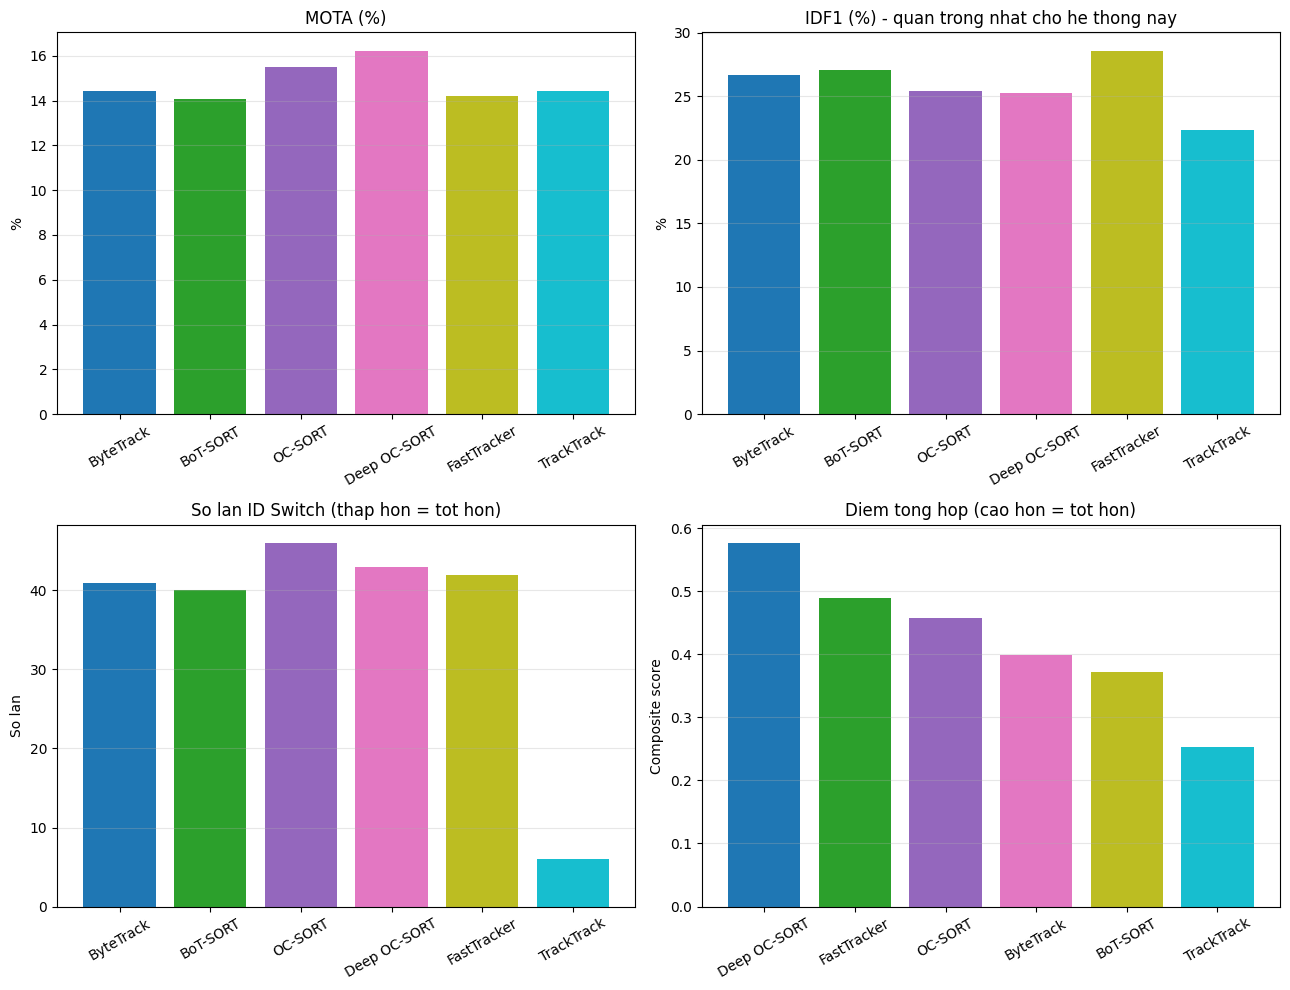

Da luu bieu do: D:\Code\Face recognition security system\ai\models\tracker_results\tracking_comparison_full.png


In [16]:
# ===== CELL 8: Ve bieu do so sanh 6 tracker =====

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

trackers = comparison_df.index.tolist()
colors = plt.cm.tab10(np.linspace(0, 1, len(trackers)))

axes[0, 0].bar(trackers, comparison_df['mota'] * 100, color=colors)
axes[0, 0].set_title('MOTA (%)')
axes[0, 0].set_ylabel('%')
axes[0, 0].tick_params(axis='x', rotation=30)
axes[0, 0].grid(axis='y', alpha=0.3)

axes[0, 1].bar(trackers, comparison_df['idf1'] * 100, color=colors)
axes[0, 1].set_title('IDF1 (%) - quan trong nhat cho he thong nay')
axes[0, 1].set_ylabel('%')
axes[0, 1].tick_params(axis='x', rotation=30)
axes[0, 1].grid(axis='y', alpha=0.3)

axes[1, 0].bar(trackers, comparison_df['num_switches'], color=colors)
axes[1, 0].set_title('So lan ID Switch (thap hon = tot hon)')
axes[1, 0].set_ylabel('So lan')
axes[1, 0].tick_params(axis='x', rotation=30)
axes[1, 0].grid(axis='y', alpha=0.3)

axes[1, 1].bar(ranking_df.index, ranking_df['composite_score'], color=colors)
axes[1, 1].set_title('Diem tong hop (cao hon = tot hon)')
axes[1, 1].set_ylabel('Composite score')
axes[1, 1].tick_params(axis='x', rotation=30)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(RESULTS_DIR, 'tracking_comparison_full.png')
plt.savefig(plot_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"Da luu bieu do: {plot_path}")


## Ket luan - Huong dan doc ket qua (dien so lieu that vao sau khi chay)

**Huong dan chinh thuc tu Ultralytics ve khi nao dung tracker nao** (dung de doi
chieu voi so lieu thuc te cua ban, khong chi tin composite_score mot chieu):

- **Can nhanh nhat, don gian nhat?** -> ByteTrack (khong ReID, khong bu camera, it
  overhead nhat)
- **Camera cam tay/drone/di chuyen?** -> BoT-SORT (mac dinh, co bu chuyen dong camera)
- **Chuyen dong phi tuyen (doi huong dot ngot), khong can ReID?** -> OC-SORT
- **Canh dong nguoi, camera di chuyen, ID hay bi trung?** -> Deep OC-SORT hoac
  TrackTrack (ca 2 co appearance fusion)
- **Nguoi che khuat nhau lien tuc, real-time, khong du tai nguyen cho ReID?** ->
  FastTracker (chuyen sau ve xu ly che khuat)

**Ap dung vao he thong cua ban:** camera an ninh trong nha/van phong thuong la
**camera tinh** (khong cam tay/drone) -> theo huong dan chinh thuc, ByteTrack von
da la lua chon hop ly cho truong hop nay, KHONG can bu chuyen dong camera (BoT-SORT/
Deep OC-SORT/TrackTrack). Nhung neu video test co nhieu canh nguoi dung gan/che
khuat nhau (hanh lang dong, cua ra vao gio cao diem), so lan ID switch thuc te se la
bang chung quyet dinh co nen doi sang FastTracker (chuyen occlusion, khong ton chi
phi ReID) hay TrackTrack/Deep OC-SORT (manh hon nhung cham hon vi co ReID) khong.

**Buoc mo rong neu muon thu nghiem sau hon (khong bat buoc):** bat `with_reid: True`
cho BoT-SORT/Deep OC-SORT/TrackTrack bang cach tao file YAML tuy chinh (copy tu
`ultralytics/cfg/trackers/`, sua `with_reid: True`), roi truyen vao
`tracker='duong_dan/custom_tracker.yaml'` - co the cai thien IDF1 nhung se cham hon.

Ghi lai tracker cuoi cung chon vao day sau khi xem so lieu that:
`___________________`